# Rhode Island patient sample points

Reproducible generation of the 5,000-patient location dataset used in `RI_simulations.jl`, `RI_STPMDP_ORS.jl`, and the manuscript's Rhode Island generalizability analyses.

The canonical output for the paper is `../sampled_points/RI_points.csv`. This notebook reproduces the same methodology with a fixed random seed and writes its output to a separately-named file (`../sampled_points/RI_points_regenerated.csv`) so the canonical file is never accidentally overwritten.

## Methods overview

Identical to the California pipeline (`filter_points_CA.ipynb`), with two regional substitutions:

1. The population raster is **masked to Rhode Island** (state FIPS 44) using TIGER/Line census-tract polygons rather than to the Bay Area using ZIP polygons.
2. The same TIGER/Line shapefile serves as the **land filter** in Step 4. Because TIGER census tracts are land-only by construction, no separate Natural Earth filter is required; the spatial join attaches census-tract attributes (`STATEFP`, `COUNTYFP`, `TRACTCE`, `GEOID`, …) to each row, matching the canonical RI schema.

Output: one row per simulated patient encounter with `Longitude`, `Latitude`, WKT `geometry`, and per-tract identifiers.

## Data sources

| Dataset | Vintage | Used for | Source |
|---|---|---|---|
| Meta/CIESIN US high-resolution population density (30 m) | 2019-07-01 | Sampling weights (Steps 1–2) | [HDX](https://data.humdata.org/dataset/united-states-high-resolution-population-density-maps-demographic-estimates) |
| US Census Bureau TIGER/Line census tracts, RI (state FIPS 44) | 2020 release | Region mask + land filter | [Census TIGER/Line](https://www2.census.gov/geo/tiger/TIGER2020/TRACT/) |

Place all input files under `./data/` before running. See `README.md` for setup.

## Reproducibility

| Parameter | Value |
|---|---|
| Random seed | `42` |
| Target final sample size | `5000` |
| Initial oversample factor | `1.10` |
| Python interpreter | 3.11+ recommended |
| Pinned dependencies | `requirements.txt` |

Re-running with the same seed reproduces this notebook's output exactly. The canonical `RI_points.csv` was generated with a different seed; the regenerated CSV is statistically equivalent but not bit-identical.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- Reproducibility ----------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Sampling parameters ------------------------------------------------------
NUM_SAMPLES = 10_000
OVERSAMPLE_FACTOR = 1.10
DROP_DUPLICATES = False

# --- Paths --------------------------------------------------------------------
DATA_DIR = Path("data")
VRT_FILE = DATA_DIR / "population_usa_2019-07-01.vrt"
# Adjust this path if you downloaded a different TIGER/Line vintage (e.g. tl_2021_44_tract.shp).
TRACTS_SHP = DATA_DIR / "tl_2020_44_tract.shp"

OUT_DIR = Path("../sampled_points")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = OUT_DIR / "RI_points_regenerated.csv"


## Step 1 — Mask the population raster to Rhode Island

We clip the Meta/CIESIN raster to the union of all Rhode Island census tracts. The masked raster is returned in WGS 84 (EPSG:4326).

In [2]:
def load_population_masked(vrt_path: Path, region_shp_path: Path):
    """Open a population raster and mask it to a region polygon."""
    region = gpd.read_file(region_shp_path)
    with rasterio.open(vrt_path) as src:
        if str(region.crs) != src.crs.to_string():
            region = region.to_crs(src.crs)
        out_image, transform = mask(src, region.geometry, crop=True)
        nodata = src.meta["nodata"]
    population = np.where(out_image[0] == nodata, np.nan, out_image[0])
    return population, transform


population, transform = load_population_masked(VRT_FILE, TRACTS_SHP)
n_valid_cells = int(np.sum(~np.isnan(population)))
print(f"Raster shape: {population.shape}  ({n_valid_cells:,} valid cells inside Rhode Island)")


Raster shape: (3324, 2948)  (419,494 valid cells inside Rhode Island)


## Step 2 — Population-weighted sample with oversampling

In [3]:
def sample_population_weighted(population: np.ndarray, transform, n: int, rng: np.random.Generator):
    """Draw n (lon, lat) samples from a population raster, weighted by cell population."""
    flat = population.flatten()
    valid = np.flatnonzero(flat > 0)
    weights = flat[valid] / flat[valid].sum()
    chosen = rng.choice(valid, size=n, p=weights)
    rows, cols = np.unravel_index(chosen, population.shape)
    return [rasterio.transform.xy(transform, r, c) for r, c in zip(rows, cols)]


rng = np.random.default_rng(RANDOM_SEED)
n_initial = int(NUM_SAMPLES * OVERSAMPLE_FACTOR)
sample_lonlat = sample_population_weighted(population, transform, n_initial, rng)
print(f"Drew {len(sample_lonlat):,} points (oversample = {NUM_SAMPLES:,} × {OVERSAMPLE_FACTOR})")


Drew 5,500 points (oversample = 5,000 × 1.1)


## Step 3 — Inspect duplicate coordinates

Same mechanism as the CA notebook: replacement sampling on a discrete ~30 m grid produces ~1 % duplicate-coordinate rows at 5,000 draws. These are legitimate outcomes of the population-weighted distribution and are kept by default (`DROP_DUPLICATES = False`), matching the canonical CSV.

In [4]:
points = pd.DataFrame(sample_lonlat, columns=["longitude", "latitude"])

duplicated = points.duplicated(subset=["longitude", "latitude"], keep=False)
n_dup_rows = int(duplicated.sum())
n_dup_groups = int(points.loc[duplicated, ["longitude", "latitude"]].drop_duplicates().shape[0])
print(f"Duplicate-coordinate rows: {n_dup_rows:,} ({n_dup_rows / len(points):.2%})")
print(f"Distinct repeated locations: {n_dup_groups:,}")

if DROP_DUPLICATES:
    before = len(points)
    points = points.drop_duplicates(subset=["longitude", "latitude"]).reset_index(drop=True)
    print(f"Dropped {before - len(points):,} duplicate rows.")
else:
    print("Keeping duplicates (DROP_DUPLICATES = False).")


Duplicate-coordinate rows: 165 (3.00%)
Distinct repeated locations: 79
Keeping duplicates (DROP_DUPLICATES = False).


## Step 4 — Land filter against TIGER/Line tracts, trim to N

The TIGER/Line census-tract shapefile serves dual duty: it bounded the population raster in Step 1, and now confirms each sampled point intersects a real tract polygon. Cell centroids landing in Narragansett Bay or other water bodies are dropped here. After the filter, we trim to exactly `NUM_SAMPLES` rows; insufficient oversample raises an informative error.

In [5]:
points_gdf = gpd.GeoDataFrame(
    points.copy(),
    geometry=[Point(xy) for xy in zip(points.longitude, points.latitude)],
    crs="EPSG:4326",
)

tracts = gpd.read_file(TRACTS_SHP)
if points_gdf.crs != tracts.crs:
    points_gdf = points_gdf.to_crs(tracts.crs)

on_land = gpd.sjoin(points_gdf, tracts, how="inner", predicate="intersects").drop(columns="index_right")
on_land = on_land.rename(columns={"longitude": "Longitude", "latitude": "Latitude"})

if len(on_land) < NUM_SAMPLES:
    raise RuntimeError(
        f"Land filter left {len(on_land):,} points, fewer than NUM_SAMPLES = {NUM_SAMPLES:,}. "
        f"Increase OVERSAMPLE_FACTOR (currently {OVERSAMPLE_FACTOR}) and re-run."
    )

dropped = len(points_gdf) - len(on_land)
final = on_land.head(NUM_SAMPLES).reset_index(drop=True)
print(f"Land filter:   {len(points_gdf):,} → {len(on_land):,}  ({dropped} dropped to water)")
print(f"Trim to N:     {len(on_land):,} → {len(final):,}")
print(f"Output columns: {list(final.columns)}")

final.to_csv(OUTPUT_CSV, index=False)
print(f"\nWrote {OUTPUT_CSV}")


Land filter:   5,500 → 5,500  (0 dropped to water)
Trim to N:     5,500 → 5,000
Output columns: ['Longitude', 'Latitude', 'geometry', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON']

Wrote ../sampled_points/RI_points_regenerated.csv


## Step 5 — Visualize

TIGER/Line tract polygons provide visual context for Rhode Island; sampled points are overlaid in red. Both layers are reprojected to WGS 84.

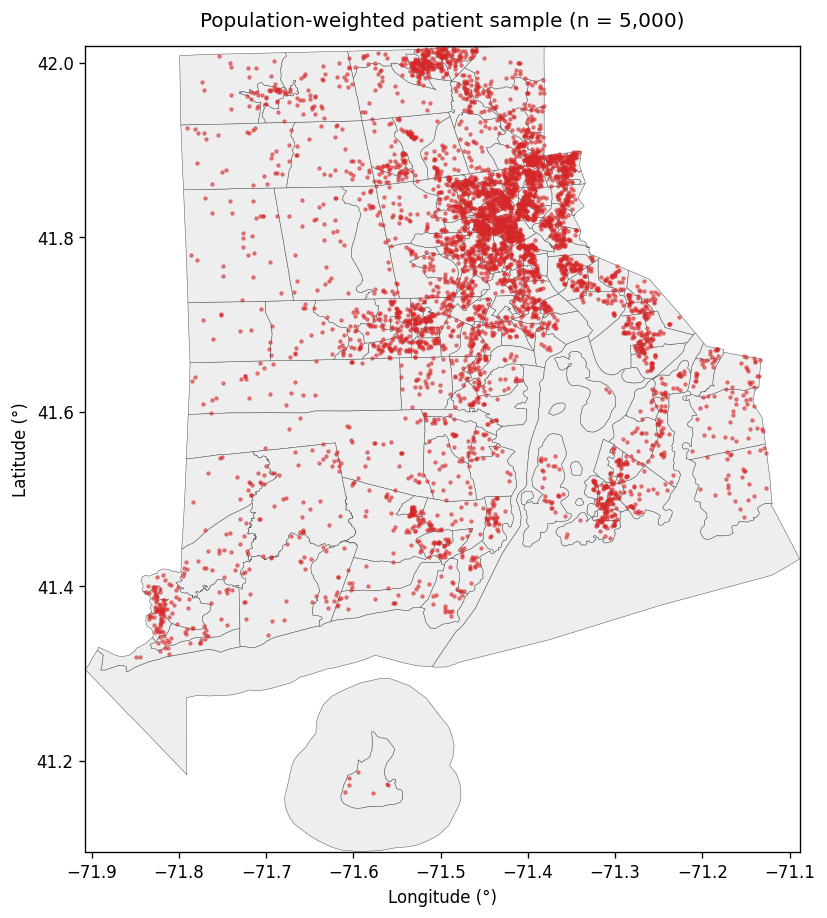

In [6]:
ri_outline = gpd.read_file(TRACTS_SHP).to_crs("EPSG:4326")
points_4326 = final.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(7, 9), dpi=120)
ri_outline.plot(ax=ax, color="#eeeeee", edgecolor="#555555", linewidth=0.3)
points_4326.plot(ax=ax, marker="o", color="#d62728", markersize=3, alpha=0.5)

xmin, ymin, xmax, ymax = ri_outline.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Population-weighted patient sample (n = {len(final):,})", pad=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## Summary

The notebook produced `../sampled_points/RI_points_regenerated.csv`. Side-by-side comparison with the canonical file checked into the repo:

In [7]:
CANONICAL_CSV = Path("..") / "sampled_points" / "RI_points.csv"

summary = pd.DataFrame(
    {
        "Canonical": [
            CANONICAL_CSV.name,
            int(pd.read_csv(CANONICAL_CSV).shape[0]) if CANONICAL_CSV.exists() else None,
            ", ".join(pd.read_csv(CANONICAL_CSV, nrows=0).columns) if CANONICAL_CSV.exists() else None,
        ],
        "Regenerated (this run)": [
            OUTPUT_CSV.name,
            len(final),
            ", ".join(final.columns),
        ],
    },
    index=["File", "Row count", "Columns"],
)
summary


,Canonical,Regenerated (this run)
File,RI_points.csv,RI_points_regenerated.csv
Row count,5000,5000
Columns,"Longitude, Latitude, geometry, STATEFP, COUNTY...","Longitude, Latitude, geometry, STATEFP, COUNTY..."
